In [1]:
# Data Loading & Preprocessing
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.ensemble import IsolationForest

DATA_DIR = Path("../data")

INDEX_COLS = ["unit_number", "time_in_cycles"]
SETTING_COLS = ["op_setting_1", "op_setting_2", "op_setting_3"]
SENSOR_COLS = [f"sensor_{i}" for i in range(1, 22)]
COLUMN_NAMES = INDEX_COLS + SETTING_COLS + SENSOR_COLS

train = pd.read_csv(DATA_DIR / "train_FD001.txt", sep=r"\s+", header=None, names=COLUMN_NAMES)
test = pd.read_csv(DATA_DIR / "test_FD001.txt", sep=r"\s+", header=None, names=COLUMN_NAMES)
rul = pd.read_csv(DATA_DIR / "RUL_FD001.txt", sep=r"\s+", header=None, names=["RUL"])
rul["unit_number"] = rul.index + 1

# Add RUL to training set (max cycle per engine - current cycle)
train["RUL"] = train.groupby("unit_number")["time_in_cycles"].transform("max") - train["time_in_cycles"]

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Engines in train:", train["unit_number"].nunique())
train.head()

Train shape: (20631, 27)
Test shape: (13096, 26)
Engines in train: 100


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [2]:
# Sensor Mapping
T30_COL = "sensor_3"   # Total temperature at HPC outlet (T30)
T50_COL = "sensor_4"   # Total temperature at LPT outlet (T50)

print(train[[T30_COL, T50_COL]].describe())
print("\nMissing values:", train[[T30_COL, T50_COL]].isna().sum().sum())

           sensor_3      sensor_4
count  20631.000000  20631.000000
mean    1590.523119   1408.933782
std        6.131150      9.000605
min     1571.040000   1382.250000
25%     1586.260000   1402.360000
50%     1590.100000   1408.040000
75%     1594.380000   1414.555000
max     1616.910000   1441.490000

Missing values: 0


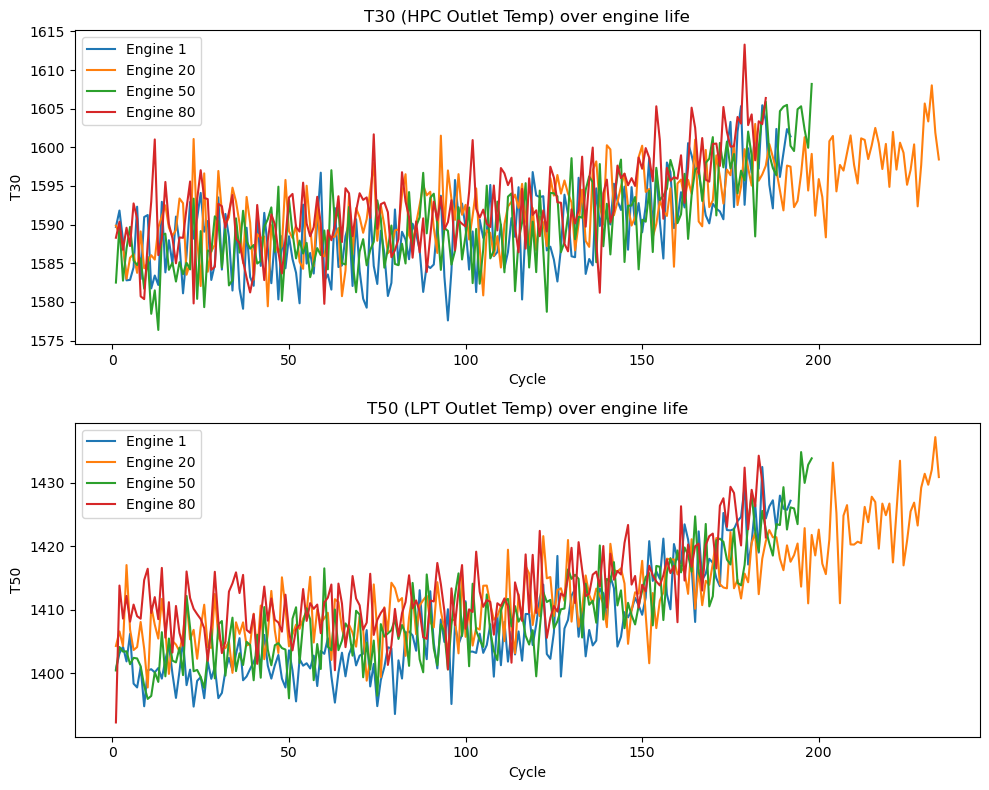

In [3]:
# Sample Unit Plot
import matplotlib.pyplot as plt

sample_units = [1, 20, 50, 80]

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=False)

for unit in sample_units:
    unit_data = train[train["unit_number"] == unit]
    axes[0].plot(unit_data["time_in_cycles"], unit_data[T30_COL], label=f"Engine {unit}")
    axes[1].plot(unit_data["time_in_cycles"], unit_data[T50_COL], label=f"Engine {unit}")

axes[0].set_title("T30 (HPC Outlet Temp) over engine life")
axes[0].set_xlabel("Cycle")
axes[0].set_ylabel("T30")
axes[0].legend()

axes[1].set_title("T50 (LPT Outlet Temp) over engine life")
axes[1].set_xlabel("Cycle")
axes[1].set_ylabel("T50")
axes[1].legend()

plt.tight_layout()
plt.show()

Overall T30-T50 correlation: 0.6784
T30-RUL correlation: -0.5845
T50-RUL correlation: -0.6789


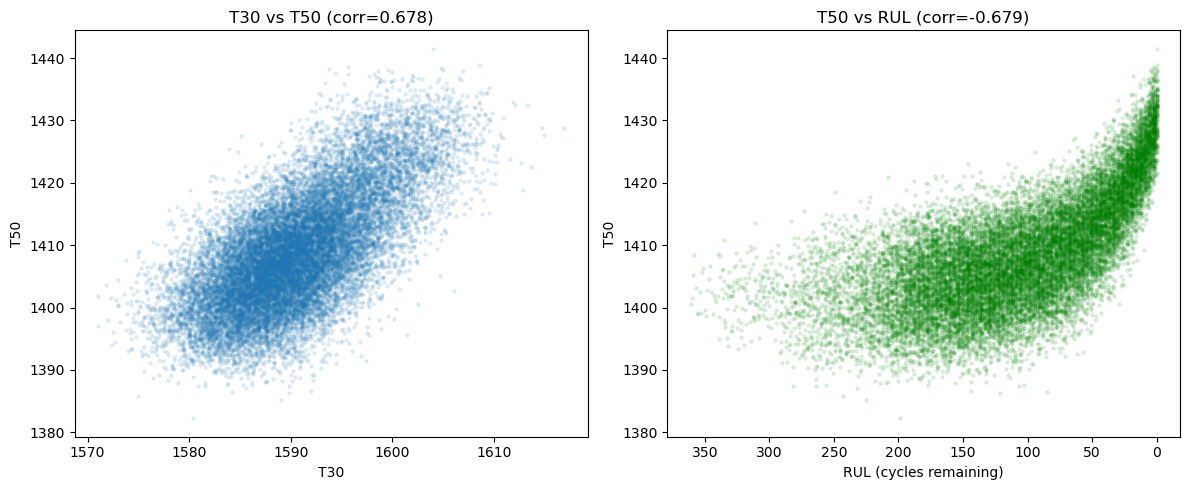

In [4]:
# RUL correlation
overall_corr = train[[T30_COL, T50_COL]].corr().iloc[0, 1]
print(f"Overall T30-T50 correlation: {overall_corr:.4f}")

# Correlation with RUL (negative expected: as RUL drops, temps rise)
corr_t30_rul = train[[T30_COL, "RUL"]].corr().iloc[0, 1]
corr_t50_rul = train[[T50_COL, "RUL"]].corr().iloc[0, 1]
print(f"T30-RUL correlation: {corr_t30_rul:.4f}")
print(f"T50-RUL correlation: {corr_t50_rul:.4f}")

# Scatter plot to visualize relationship
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(train[T30_COL], train[T50_COL], alpha=0.1, s=5)
axes[0].set_xlabel("T30")
axes[0].set_ylabel("T50")
axes[0].set_title(f"T30 vs T50 (corr={overall_corr:.3f})")

axes[1].scatter(train["RUL"], train[T50_COL], alpha=0.1, s=5, color="green")
axes[1].set_xlabel("RUL (cycles remaining)")
axes[1].set_ylabel("T50")
axes[1].set_title(f"T50 vs RUL (corr={corr_t50_rul:.3f})")
axes[1].invert_xaxis()  # so RUL decreasing (approaching failure) reads left to right

plt.tight_layout()
plt.show()

In [5]:
# Method 1 - Rolling Z-Score Method
def rolling_zscore(unit_df, sensor_col, baseline_window=20, rolling_window=10):
    """
    baseline_window: number of early cycles used to define 'normal' mean/std
    rolling_window: smoothing window applied before scoring, to reduce noise
    """
    baseline_mean = unit_df[sensor_col].iloc[:baseline_window].mean()
    baseline_std = unit_df[sensor_col].iloc[:baseline_window].std()

    rolling_signal = unit_df[sensor_col].rolling(rolling_window, min_periods=rolling_window).mean()
    z_scores = (rolling_signal - baseline_mean) / baseline_std

    return z_scores

# Quick test on one engine
test_unit = train[train["unit_number"] == 1].reset_index(drop=True)
z_t30 = rolling_zscore(test_unit, T30_COL)
z_t50 = rolling_zscore(test_unit, T50_COL)

print(z_t30.describe())
print(z_t50.describe())

count    183.000000
mean       0.636088
std        0.946682
min       -0.626908
25%       -0.083629
50%        0.350356
75%        1.282060
max        3.264464
Name: sensor_3, dtype: float64
count    183.000000
mean       2.087196
std        2.534028
min       -0.841776
25%        0.064487
50%        1.471469
75%        3.011047
max        8.638460
Name: sensor_4, dtype: float64


In [6]:
# Final Z-score Thresholds ===
FINAL_THRESHOLDS = {T30_COL: 2.0, T50_COL: 2.5}
print(FINAL_THRESHOLDS)

{'sensor_3': 2.0, 'sensor_4': 2.5}


In [7]:
# Threshold sweep
def evaluate_threshold(sensor_col, threshold, baseline_window=20, rolling_window=10, healthy_cutoff_pct=50):
    """
    healthy_cutoff_pct: cycles before this % of engine life are considered 'known healthy'
    (from our EDA, drift onset averages ~68%, so anything before 50% is a safe healthy zone)
    """
    detected = 0
    missed = 0
    flag_timings = []
    false_positive_engines = 0

    for unit in train["unit_number"].unique():
        unit_df = train[train["unit_number"] == unit].reset_index(drop=True)
        max_cycle = unit_df["time_in_cycles"].max()

        z = rolling_zscore(unit_df, sensor_col, baseline_window, rolling_window)
        flag_cycle = unit_df["time_in_cycles"][z > threshold].min()

        if pd.notna(flag_cycle):
            detected += 1
            flag_timings.append(flag_cycle / max_cycle * 100)

            # Check if it flagged during the "known healthy" early window (false positive)
            healthy_cutoff_cycle = max_cycle * (healthy_cutoff_pct / 100)
            if flag_cycle < healthy_cutoff_cycle:
                false_positive_engines += 1
        else:
            missed += 1

    return {
        "threshold": threshold,
        "detected": detected,
        "missed": missed,
        "mean_flag_pct": np.mean(flag_timings) if flag_timings else None,
        "false_positive_engines": false_positive_engines,
    }

thresholds_to_test = [1.5, 2.0, 2.5, 3.0, 3.5]

print("=== T30 threshold sweep ===")
t30_sweep = [evaluate_threshold(T30_COL, t) for t in thresholds_to_test]
print(pd.DataFrame(t30_sweep))

print("\n=== T50 threshold sweep (for comparison) ===")
t50_sweep = [evaluate_threshold(T50_COL, t) for t in thresholds_to_test]
print(pd.DataFrame(t50_sweep))

=== T30 threshold sweep ===
   threshold  detected  missed  mean_flag_pct  false_positive_engines
0        1.5       100       0      71.691373                       7
1        2.0       100       0      81.393906                       0
2        2.5        93       7      87.718271                       0
3        3.0        80      20      90.317208                       0
4        3.5        64      36      93.066569                       0

=== T50 threshold sweep (for comparison) ===
   threshold  detected  missed  mean_flag_pct  false_positive_engines
0        1.5       100       0      58.821534                      18
1        2.0       100       0      68.414046                       7
2        2.5       100       0      75.954566                       1
3        3.0       100       0      81.385708                       0
4        3.5        99       1      85.203957                       0


In [8]:
# Add_baseline_features (fixed)
baseline_window = 20
rolling_window = 10

def add_baseline_features(df, sensor_cols, baseline_window, rolling_window):
    df = df.sort_values(['unit_number', 'time_in_cycles']).copy()
    for col in sensor_cols:
        # Smoothed signal (same as rolling_signal in your Z-score function)
        df[f'{col}_smooth'] = (
            df.groupby('unit_number')[col]
              .transform(lambda x: x.rolling(rolling_window, min_periods=rolling_window).mean())
        )
        # Per-unit baseline mean/std from first N cycles
        baseline_stats = (
            df.groupby('unit_number')[col]
              .apply(lambda x: x.iloc[:baseline_window].mean())
        )
        baseline_std = (
            df.groupby('unit_number')[col]
              .apply(lambda x: x.iloc[:baseline_window].std())
        )
        df[f'{col}_baseline_mean'] = df['unit_number'].map(baseline_stats)
        df[f'{col}_baseline_std'] = df['unit_number'].map(baseline_std)
        # Deviation from baseline (this is literally the numerator of your z-score)
        df[f'{col}_dev'] = df[f'{col}_smooth'] - df[f'{col}_baseline_mean']
    return df

sensor_cols = [T30_COL, T50_COL]
train = add_baseline_features(train, sensor_cols, baseline_window, rolling_window)

In [9]:
# Method 2: Isolation Forest Method
baseline_window = 30  # increased from 20
rolling_window = 10
feature_cols = [f'{T30_COL}_dev', f'{T50_COL}_dev']
k = 2
min_consecutive = 3

def first_sustained_flag(flags, min_consecutive=3):
    count = 0
    for i, f in enumerate(flags):
        if f == -1:
            count += 1
            if count >= min_consecutive:
                return i - min_consecutive + 1
        else:
            count = 0
    return None

iso_results = []
train['iso_score'] = np.nan
train['iso_flag'] = np.nan

for unit in train['unit_number'].unique():
    unit_mask = train['unit_number'] == unit
    unit_df = train[unit_mask].sort_values('time_in_cycles').reset_index(drop=True)
    
    X_unit = unit_df[feature_cols]
    X_baseline = X_unit.iloc[rolling_window:baseline_window]  # cycles 11-30 now
    
    model = IsolationForest(n_estimators=100, random_state=42)
    model.fit(X_baseline)
    
    scores = model.decision_function(X_unit)
    baseline_scores = model.decision_function(X_baseline)
    
    threshold = baseline_scores.mean() - k * baseline_scores.std()
    flags = np.where(scores < threshold, -1, 1)
    flags[:rolling_window] = 1
    
    train.loc[unit_mask, 'iso_score'] = scores
    train.loc[unit_mask, 'iso_flag'] = flags
    
    max_cycle = unit_df['time_in_cycles'].max()
    first_flag_idx = first_sustained_flag(flags, min_consecutive)
    first_flag = unit_df['time_in_cycles'].iloc[first_flag_idx] if first_flag_idx is not None else None
    
    iso_results.append({
        "unit_number": unit,
        "max_cycle": max_cycle,
        "iso_flag_cycle": first_flag,
        "iso_flag_pct": (first_flag / max_cycle * 100) if first_flag is not None else None
    })

iso_results_df = pd.DataFrame(iso_results)
iso_results_df.to_csv("../outputs/iso_results.csv", index=False)

flagged_count = iso_results_df['iso_flag_cycle'].notna().sum()
print(f"Isolation Forest flagged {flagged_count} out of 100 units")
print(iso_results_df[["iso_flag_cycle", "iso_flag_pct"]].describe())



Isolation Forest flagged 90 out of 100 units
       iso_flag_cycle  iso_flag_pct
count       90.000000     90.000000
mean        52.933333     26.437331
std         23.478798     11.307327
min         29.000000     11.151079
25%         36.250000     18.213828
50%         46.500000     23.349072
75%         65.750000     33.704545
max        184.000000     53.958944


In [10]:
# Isolation Forest 
def pct_time_anomalous_after_flag(flags, flag_idx):
    post_flag = flags[flag_idx:]
    return (post_flag == -1).mean()

recovery_check = []
for unit in train['unit_number'].unique():
    unit_mask = train['unit_number'] == unit
    unit_df = train[unit_mask].sort_values('time_in_cycles').reset_index(drop=True)
    flags = unit_df['iso_flag'].values
    row = iso_results_df[iso_results_df['unit_number'] == unit]
    flag_cycle = row['iso_flag_cycle'].values[0]
    if pd.notna(flag_cycle):
        flag_idx = unit_df[unit_df['time_in_cycles'] == flag_cycle].index[0]
        pct_anomalous_after = pct_time_anomalous_after_flag(flags, flag_idx)
        recovery_check.append({"unit_number": unit, "pct_anomalous_after_flag": pct_anomalous_after})

recovery_df = pd.DataFrame(recovery_check)
print(recovery_df['pct_anomalous_after_flag'].describe())
print(f"\nUnits where <50% of remaining life stays anomalous: {(recovery_df['pct_anomalous_after_flag'] < 0.5).sum()} out of {len(recovery_df)}")

count    90.000000
mean      0.745296
std       0.250241
min       0.019355
25%       0.686978
50%       0.799225
75%       0.929184
max       1.000000
Name: pct_anomalous_after_flag, dtype: float64

Units where <50% of remaining life stays anomalous: 11 out of 90


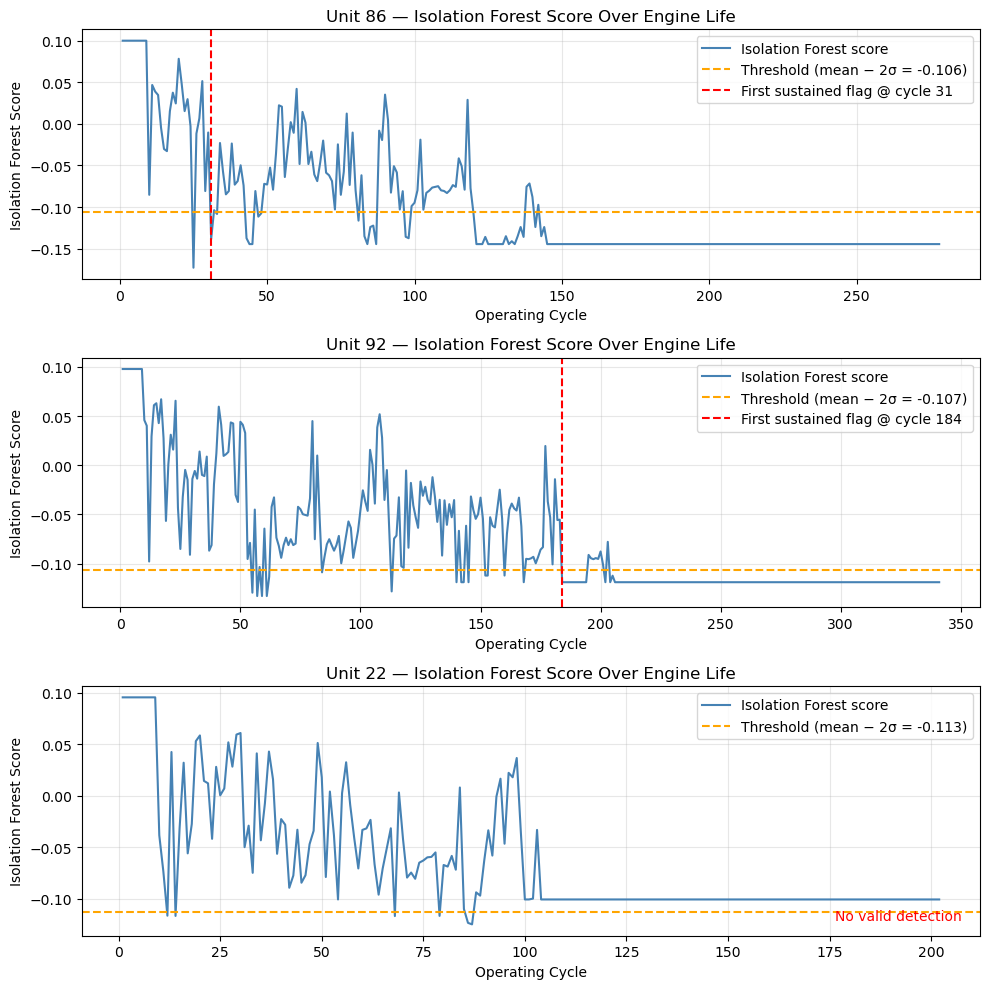

In [11]:
# Isolation Forest final fit
import matplotlib.pyplot as plt
import pandas as pd

# Earliest detected unit
flagged = iso_results_df[iso_results_df['iso_flag_pct'].notna()]

early_unit = flagged.loc[
    flagged['iso_flag_pct'].idxmin(), 'unit_number'
]

# Latest detected unit
late_unit = flagged.loc[
    flagged['iso_flag_pct'].idxmax(), 'unit_number'
]

# Automatically select one unflagged unit
unflagged_units = iso_results_df[
    iso_results_df['iso_flag_pct'].isna()
]['unit_number']

unflagged_unit = unflagged_units.iloc[0] if len(unflagged_units) > 0 else None

baseline_window = 30
rolling_window = 10
k = 2

units_to_plot = [early_unit, late_unit]

if unflagged_unit is not None:
    units_to_plot.append(unflagged_unit)

fig, axes = plt.subplots(
    len(units_to_plot),
    1,
    figsize=(10, 10),
    sharex=False
)

# Make axes iterable if only one unit is plotted
if len(units_to_plot) == 1:
    axes = [axes]

for ax, unit in zip(axes, units_to_plot):

    # Get engine data
    unit_df = (
        train[train['unit_number'] == unit]
        .sort_values('time_in_cycles')
        .reset_index(drop=True)
    )

    # Isolation Forest score
    ax.plot(
        unit_df['time_in_cycles'],
        unit_df['iso_score'],
        color='steelblue',
        linewidth=1.5,
        label='Isolation Forest score'
    )

    baseline_scores = unit_df['iso_score'].iloc[
        rolling_window:baseline_window
    ]

    threshold = (
        baseline_scores.mean()
        - k * baseline_scores.std()
    )

    # Plot threshold
    ax.axhline(
        threshold,
        color='orange',
        linestyle='--',
        linewidth=1.5,
        label=f'Threshold (mean − {k}σ = {threshold:.3f})'
    )

    result_row = iso_results_df[
        iso_results_df['unit_number'] == unit
    ]

    flag_cycle = result_row['iso_flag_cycle'].iloc[0]

    # Plot first sustained detection
    if pd.notna(flag_cycle):

        ax.axvline(
            flag_cycle,
            color='red',
            linestyle='--',
            linewidth=1.5,
            label=f'First sustained flag @ cycle {int(flag_cycle)}'
        )

    else:

        ax.text(
            0.98,
            0.05,
            'No valid detection',
            transform=ax.transAxes,
            ha='right',
            va='bottom',
            fontsize=10,
            color='red'
        )

    ax.set_title(
        f'Unit {unit} — Isolation Forest Score Over Engine Life'
    )

    ax.set_xlabel('Operating Cycle')
    ax.set_ylabel('Isolation Forest Score')

    ax.grid(alpha=0.3)
    ax.legend(loc='best')

plt.tight_layout()

plt.savefig(
    "../outputs/iso_score_examples_final.png",
    dpi=150,
    bbox_inches='tight'
)

plt.show()

In [12]:
# Z-score final cell
def zscore_flags_with_warmup(unit_df, sensor_col, threshold, warmup_cycles):
    z = rolling_zscore(unit_df, sensor_col)
    flag_bool = (z > threshold).values
    flags = np.where(flag_bool, -1, 1)
    flags[:warmup_cycles] = 1
    return flags

warmup_cycles = 10
min_consecutive = 3

final_results = []
for unit in train["unit_number"].unique():
    unit_df = train[train["unit_number"] == unit].sort_values("time_in_cycles").reset_index(drop=True)
    max_cycle = unit_df["time_in_cycles"].max()

    flags_t30 = zscore_flags_with_warmup(unit_df, T30_COL, FINAL_THRESHOLDS[T30_COL], warmup_cycles)
    flags_t50 = zscore_flags_with_warmup(unit_df, T50_COL, FINAL_THRESHOLDS[T50_COL], warmup_cycles)

    idx_t30 = first_sustained_flag(flags_t30, min_consecutive)
    idx_t50 = first_sustained_flag(flags_t50, min_consecutive)

    flag_t30 = unit_df["time_in_cycles"].iloc[idx_t30] if idx_t30 is not None else None
    flag_t50 = unit_df["time_in_cycles"].iloc[idx_t50] if idx_t50 is not None else None

    earliest = min([c for c in [flag_t30, flag_t50] if c is not None], default=None)

    final_results.append({
        "unit_number": unit,
        "max_cycle": max_cycle,
        "zscore_earliest_cycle": earliest,
        "zscore_earliest_pct": (earliest / max_cycle * 100) if earliest is not None else None,
    })

zscore_results_df = pd.DataFrame(final_results)
zscore_results_df.to_csv("../outputs/zscore_results.csv", index=False)
print("COLUMNS NOW:", zscore_results_df.columns.tolist())
print(zscore_results_df["zscore_earliest_pct"].describe())

COLUMNS NOW: ['unit_number', 'max_cycle', 'zscore_earliest_cycle', 'zscore_earliest_pct']
count    100.000000
mean      75.601348
std        8.272801
min       49.442379
25%       72.249104
50%       76.218405
75%       79.865619
max       92.227979
Name: zscore_earliest_pct, dtype: float64


In [13]:
# Two-way comparison
comparison_df = zscore_results_df.merge(iso_results_df, on='unit_number', suffixes=('_zscore', '_iso'))
comparison_df['detection_diff_pct'] = comparison_df['iso_flag_pct'] - comparison_df['zscore_earliest_pct']
print("=== Coverage ===")
print(f"Z-score flagged: {comparison_df['zscore_earliest_pct'].notna().sum()} / 100")
print(f"Isolation Forest flagged: {comparison_df['iso_flag_pct'].notna().sum()} / 100")
print("\n=== Timing comparison (% of engine life) ===")
print(comparison_df[['zscore_earliest_pct', 'iso_flag_pct']].describe())
print("\n=== Who detects earlier? ===")
iso_earlier = (comparison_df['detection_diff_pct'] < 0).sum()
zscore_earlier = (comparison_df['detection_diff_pct'] > 0).sum()
both_flagged = comparison_df['detection_diff_pct'].notna().sum()
print(f"Isolation Forest earlier: {iso_earlier} / {both_flagged}")
print(f"Z-score earlier: {zscore_earlier} / {both_flagged}")
print("\n=== Correlation between methods' timing ===")
valid = comparison_df.dropna(subset=['zscore_earliest_pct', 'iso_flag_pct'])
corr = valid['zscore_earliest_pct'].corr(valid['iso_flag_pct'])
print(f"Correlation: {corr:.3f}")
comparison_df.to_csv("../outputs/zscore_vs_iso_comparison.csv", index=False)

=== Coverage ===
Z-score flagged: 100 / 100
Isolation Forest flagged: 90 / 100

=== Timing comparison (% of engine life) ===
       zscore_earliest_pct  iso_flag_pct
count           100.000000     90.000000
mean             75.601348     26.437331
std               8.272801     11.307327
min              49.442379     11.151079
25%              72.249104     18.213828
50%              76.218405     23.349072
75%              79.865619     33.704545
max              92.227979     53.958944

=== Who detects earlier? ===
Isolation Forest earlier: 90 / 90
Z-score earlier: 0 / 90

=== Correlation between methods' timing ===
Correlation: 0.275


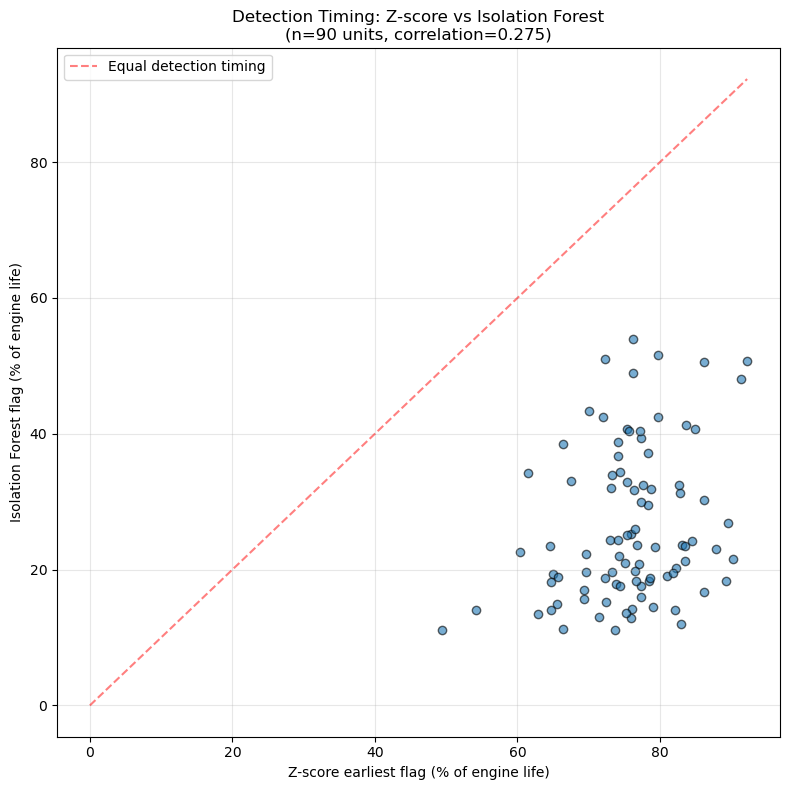

In [14]:
# Scatter Plot
fig, ax = plt.subplots(figsize=(8, 8))

valid = comparison_df.dropna(subset=['zscore_earliest_pct', 'iso_flag_pct'])

ax.scatter(valid['zscore_earliest_pct'], valid['iso_flag_pct'], alpha=0.6, edgecolor='k')

# Diagonal reference line (where both methods would agree exactly)
max_val = max(valid['zscore_earliest_pct'].max(), valid['iso_flag_pct'].max())
ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Equal detection timing')

ax.set_xlabel('Z-score earliest flag (% of engine life)')
ax.set_ylabel('Isolation Forest flag (% of engine life)')
ax.set_title(f'Detection Timing: Z-score vs Isolation Forest\n(n={len(valid)} units, correlation={corr:.3f})')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/zscore_vs_iso_scatter.png", dpi=150)
plt.show()

In [15]:
# get_healthy_data
healthy_pct = 0.3

def get_healthy_data(df, healthy_pct):
    healthy_rows = []
    for unit in df['unit_number'].unique():
        unit_df = df[df['unit_number'] == unit].sort_values('time_in_cycles')
        max_cycle = unit_df['time_in_cycles'].max()
        cutoff = int(max_cycle * healthy_pct)
        healthy_rows.append(unit_df[unit_df['time_in_cycles'] <= cutoff])
    return pd.concat(healthy_rows, ignore_index=True)

healthy_df = get_healthy_data(train, healthy_pct)
print(f"Healthy data: {len(healthy_df)} rows out of {len(train)} total ({len(healthy_df)/len(train)*100:.1f}%)")
print(healthy_df['unit_number'].nunique(), "units represented")

Healthy data: 6144 rows out of 20631 total (29.8%)
100 units represented


In [16]:
# create_sequences
sequence_length = 15
feature_cols = [T30_COL, T50_COL]  # or _dev columns - let's discuss below

def create_sequences(df, feature_cols, seq_len):
    sequences = []
    for unit in df['unit_number'].unique():
        unit_df = df[df['unit_number'] == unit].sort_values('time_in_cycles')
        data = unit_df[feature_cols].values
        
        if len(data) < seq_len:
            continue  # skip units that don't have enough healthy cycles
        
        for i in range(len(data) - seq_len + 1):
            sequences.append(data[i:i + seq_len])
    
    return np.array(sequences)

X_train_seq = create_sequences(healthy_df, feature_cols, sequence_length)
print(f"Training sequences shape: {X_train_seq.shape}")

Training sequences shape: (4744, 15, 2)


In [17]:
# StandardScaler
from sklearn.preprocessing import StandardScaler

# Flatten sequences temporarily to fit the scaler (scaler expects 2D input)
n_samples, seq_len, n_features = X_train_seq.shape
X_train_flat = X_train_seq.reshape(-1, n_features)

scaler = StandardScaler()
scaler.fit(X_train_flat)

# Scale and reshape back to sequences
X_train_scaled = scaler.transform(X_train_flat).reshape(n_samples, seq_len, n_features)

print(f"Scaled training data shape: {X_train_scaled.shape}")
print(f"Mean per feature (should be ~0): {X_train_scaled.reshape(-1, n_features).mean(axis=0)}")
print(f"Std per feature (should be ~1): {X_train_scaled.reshape(-1, n_features).std(axis=0)}")

Scaled training data shape: (4744, 15, 2)
Mean per feature (should be ~0): [-5.08627897e-12  6.26892770e-12]
Std per feature (should be ~1): [1. 1.]


In [18]:
# LSTM architecture
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense

timesteps = sequence_length  # 15
n_features = X_train_scaled.shape[2]  # 2
latent_dim = 8  # size of the compressed "summary" - a hyperparameter to tune later

# Encoder
inputs = Input(shape=(timesteps, n_features))
encoded = LSTM(32, activation='tanh', return_sequences=True)(inputs)
encoded = LSTM(latent_dim, activation='tanh', return_sequences=False)(encoded)

# Bridge: repeat the compressed vector once per timestep, so the decoder can rebuild a full sequence
decoded = RepeatVector(timesteps)(encoded)

# Decoder
decoded = LSTM(latent_dim, activation='tanh', return_sequences=True)(decoded)
decoded = LSTM(32, activation='tanh', return_sequences=True)(decoded)
decoded = TimeDistributed(Dense(n_features))(decoded)

autoencoder = Model(inputs, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 15, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 15, 32)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 8)              │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 15, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 15, 8)          │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 15, 32)         │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 15, 2)          │            66 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,650 (45.51 KB)

 Trainable params: 11,650 (45.51 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Training
history = autoencoder.fit(
    X_train_scaled, X_train_scaled,  # input AND target are the same - it's reconstructing itself
    epochs=50,
    batch_size=32,
    validation_split=0.1,  # holds out 10% of healthy sequences to monitor overfitting
    shuffle=True,
    verbose=1
)

Epoch 1/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - loss: 0.7186 - val_loss: 0.5898
Epoch 2/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.5965 - val_loss: 0.5554
Epoch 3/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.5700 - val_loss: 0.5431
Epoch 4/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.5555 - val_loss: 0.5300
Epoch 5/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.5423 - val_loss: 0.5182
Epoch 6/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.5318 - val_loss: 0.5118
Epoch 7/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.5258 - val_loss: 0.5083
Epoch 8/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.5223 - val_loss: 0.5062
Epoch 9/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.5201 - val_loss: 0.5053
Epoch 10/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.5172 - val_loss: 0.5012
Epoch 11/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.5130 - val_loss: 0.4960
Epoch 12/50
134/134 ━━━━━━━━━━━━━━━━━━━━

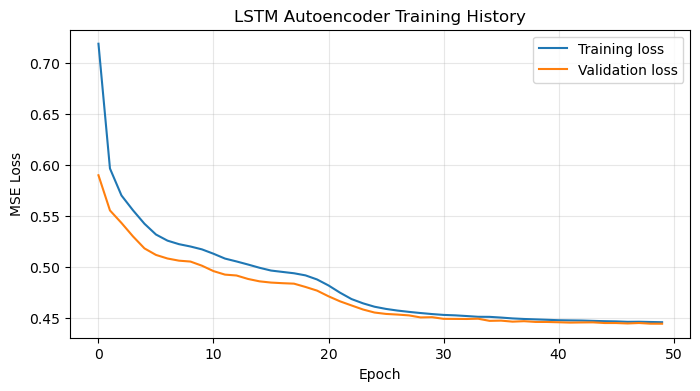

In [20]:
# Training history plot
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('LSTM Autoencoder Training History')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("../outputs/lstm_training_history.png", dpi=150)
plt.show()

In [21]:
# Full-life scoring
def create_sequences_with_labels(df, feature_cols, seq_len):
    """Returns sequences PLUS the unit_number and end-cycle for each sequence, so we can trace scores back."""
    sequences = []
    meta = []  # (unit_number, cycle_at_end_of_window)
    
    for unit in df['unit_number'].unique():
        unit_df = df[df['unit_number'] == unit].sort_values('time_in_cycles').reset_index(drop=True)
        data = unit_df[feature_cols].values
        cycles = unit_df['time_in_cycles'].values
        
        if len(data) < seq_len:
            continue
        
        for i in range(len(data) - seq_len + 1):
            sequences.append(data[i:i + seq_len])
            meta.append((unit, cycles[i + seq_len - 1]))  # label with the LAST cycle in the window
    
    return np.array(sequences), meta

# Build sequences across FULL lifespan (not just healthy_df)
X_full_seq, meta_full = create_sequences_with_labels(train, feature_cols, sequence_length)
print(f"Full sequences shape: {X_full_seq.shape}")

# Scale using the SAME scaler fit on healthy data only
n_samples_full = X_full_seq.shape[0]
X_full_flat = X_full_seq.reshape(-1, n_features)
X_full_scaled = scaler.transform(X_full_flat).reshape(n_samples_full, sequence_length, n_features)

# Get reconstructions and compute per-sequence MSE
reconstructions = autoencoder.predict(X_full_scaled, verbose=1)
reconstruction_errors = np.mean(np.square(X_full_scaled - reconstructions), axis=(1, 2))

print(f"Reconstruction errors shape: {reconstruction_errors.shape}")
print(f"Error range: {reconstruction_errors.min():.4f} to {reconstruction_errors.max():.4f}")

Full sequences shape: (19231, 15, 2)
601/601 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step
Reconstruction errors shape: (19231,)
Error range: 0.0925 to 4.0713


In [22]:
# Build a dataframe linking each sequence's error back to its unit and end-cycle
results_meta_df = pd.DataFrame(meta_full, columns=['unit_number', 'time_in_cycles'])
results_meta_df['recon_error'] = reconstruction_errors

# Determine threshold from HEALTHY reconstruction errors only
healthy_reconstructions = autoencoder.predict(X_train_scaled, verbose=0)
healthy_recon_errors = np.mean(np.square(X_train_scaled - healthy_reconstructions), axis=(1, 2))

k = 2  # same spirit as before: mean + k*std
threshold = healthy_recon_errors.mean() + k * healthy_recon_errors.std()
print(f"Threshold: {threshold:.4f}")
print(f"Healthy error stats: mean={healthy_recon_errors.mean():.4f}, std={healthy_recon_errors.std():.4f}")

results_meta_df['lstm_flag'] = np.where(results_meta_df['recon_error'] > threshold, -1, 1)

Threshold: 0.7349
Healthy error stats: mean=0.4454, std=0.1447


In [23]:
# Final LSTM results
def first_sustained_flag_after_cutoff(unit_df, min_consecutive, healthy_cutoff_cycle):
    eligible = unit_df[unit_df['time_in_cycles'] > healthy_cutoff_cycle].reset_index(drop=True)
    flags = eligible['lstm_flag'].values
    idx = first_sustained_flag(flags, min_consecutive)
    return eligible['time_in_cycles'].iloc[idx] if idx is not None else None

lstm_results = []
for unit in results_meta_df['unit_number'].unique():
    unit_df = results_meta_df[results_meta_df['unit_number'] == unit].sort_values('time_in_cycles').reset_index(drop=True)
    max_cycle = train[train['unit_number'] == unit]['time_in_cycles'].max()
    healthy_cutoff_cycle = int(max_cycle * healthy_pct)  # same 30% used for training
    
    first_flag_cycle = first_sustained_flag_after_cutoff(unit_df, min_consecutive, healthy_cutoff_cycle)
    
    lstm_results.append({
        "unit_number": unit,
        "max_cycle": max_cycle,
        "lstm_flag_cycle": first_flag_cycle,
        "lstm_flag_pct": (first_flag_cycle / max_cycle * 100) if first_flag_cycle is not None else None
    })

lstm_results_df = pd.DataFrame(lstm_results)
lstm_results_df.to_csv("../outputs/lstm_results.csv", index=False)

flagged_count = lstm_results_df['lstm_flag_cycle'].notna().sum()
print(f"LSTM Autoencoder flagged {flagged_count} out of 100 units")
print(lstm_results_df[["lstm_flag_cycle", "lstm_flag_pct"]].describe())

LSTM Autoencoder flagged 99 out of 100 units
       lstm_flag_cycle  lstm_flag_pct
count        99.000000      99.000000
mean        169.020202      81.352288
std          53.626254      18.071524
min          42.000000      30.656934
25%         147.000000      78.295136
50%         174.000000      88.343558
75%         194.000000      93.114583
max         316.000000      97.206704


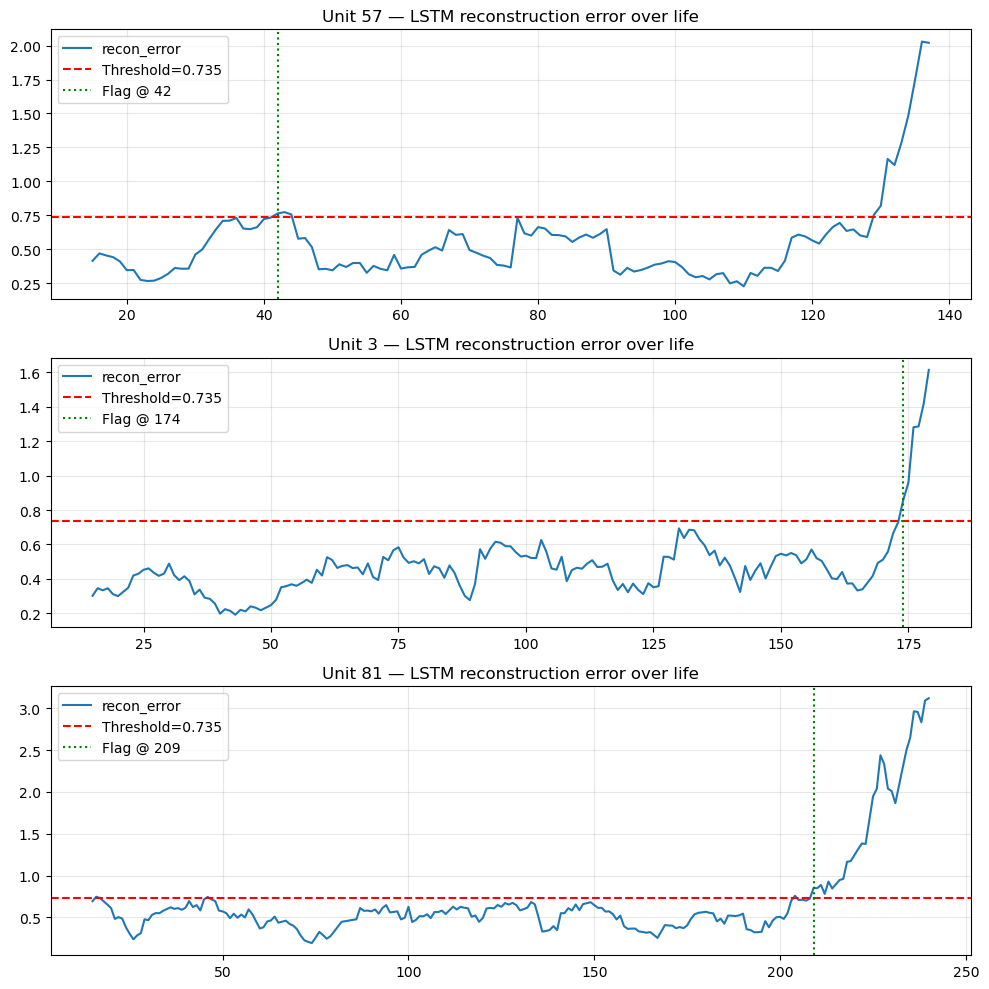

In [24]:
# Threshold + lstm_flag
fig, axes = plt.subplots(3, 1, figsize=(10, 10))

sample_units = [lstm_results_df.loc[lstm_results_df['lstm_flag_pct'].idxmin(), 'unit_number'],
                lstm_results_df.loc[lstm_results_df['lstm_flag_pct'].idxmax(), 'unit_number'],
                lstm_results_df['unit_number'].sample(1, random_state=1).values[0]]

for ax, unit in zip(axes, sample_units):
    unit_df = results_meta_df[results_meta_df['unit_number'] == unit].sort_values('time_in_cycles')
    ax.plot(unit_df['time_in_cycles'], unit_df['recon_error'], label='recon_error')
    ax.axhline(threshold, color='red', linestyle='--', label=f'Threshold={threshold:.3f}')
    
    flag_row = lstm_results_df[lstm_results_df['unit_number'] == unit]
    flag_cycle = flag_row['lstm_flag_cycle'].values[0]
    if pd.notna(flag_cycle):
        ax.axvline(flag_cycle, color='green', linestyle=':', label=f'Flag @ {int(flag_cycle)}')
    
    ax.set_title(f"Unit {int(unit)} — LSTM reconstruction error over life")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/lstm_recon_error_examples.png", dpi=150)
plt.show()

In [25]:
# Verification print
print(lstm_results_df['lstm_flag_pct'].describe())
print(lstm_results_df['lstm_flag_pct'].notna().sum())

count    99.000000
mean     81.352288
std      18.071524
min      30.656934
25%      78.295136
50%      88.343558
75%      93.114583
max      97.206704
Name: lstm_flag_pct, dtype: float64
99


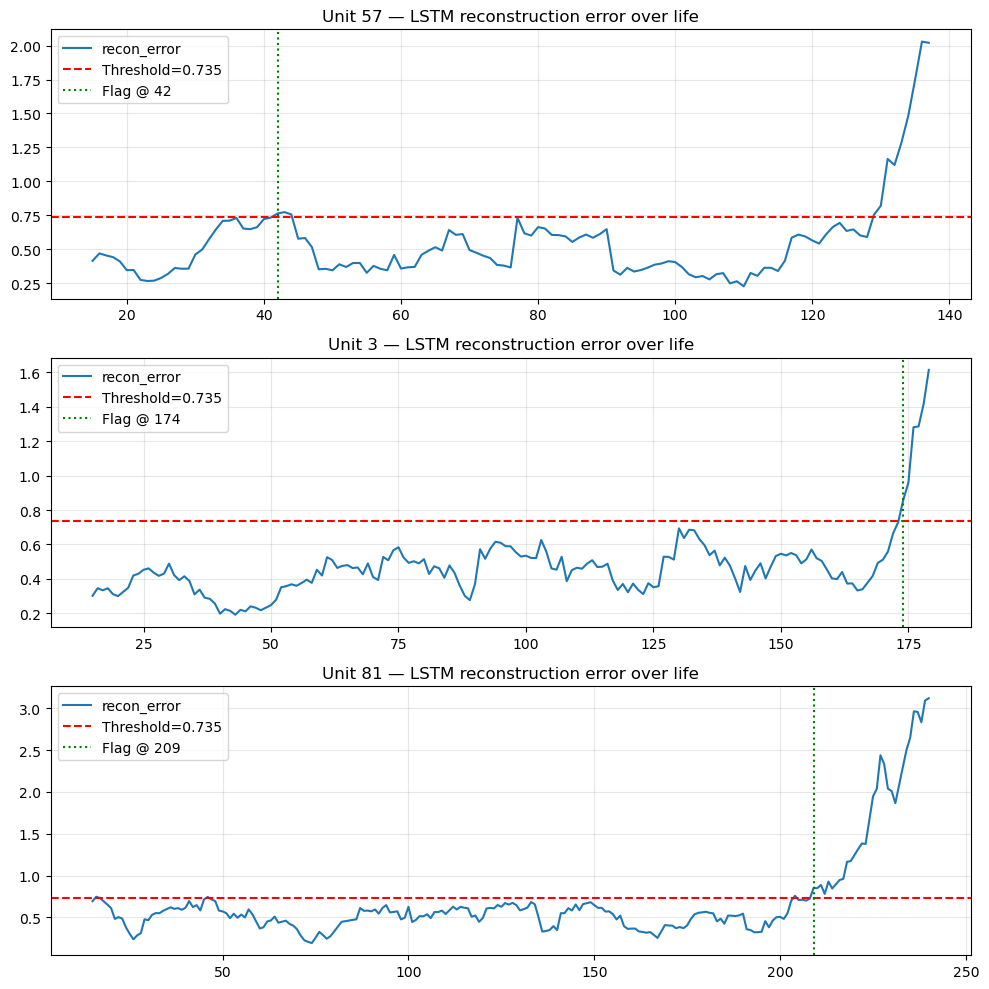

In [26]:
# Reconstruction-error plot
fig, axes = plt.subplots(3, 1, figsize=(10, 10))
sample_units = [lstm_results_df.loc[lstm_results_df['lstm_flag_pct'].idxmin(), 'unit_number'],
                lstm_results_df.loc[lstm_results_df['lstm_flag_pct'].idxmax(), 'unit_number'],
                lstm_results_df['unit_number'].sample(1, random_state=1).values[0]]
for ax, unit in zip(axes, sample_units):
    unit_df = results_meta_df[results_meta_df['unit_number'] == unit].sort_values('time_in_cycles')
    ax.plot(unit_df['time_in_cycles'], unit_df['recon_error'], label='recon_error')
    ax.axhline(threshold, color='red', linestyle='--', label=f'Threshold={threshold:.3f}')
    flag_row = lstm_results_df[lstm_results_df['unit_number'] == unit]
    flag_cycle = flag_row['lstm_flag_cycle'].values[0]
    if pd.notna(flag_cycle):
        ax.axvline(flag_cycle, color='green', linestyle=':', label=f'Flag @ {int(flag_cycle)}')
    ax.set_title(f"Unit {int(unit)} — LSTM reconstruction error over life")
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/lstm_recon_error_examples.png", dpi=150)
plt.show()

In [27]:
# k=1.5 sensitivity
k_test = 1.5
threshold_test = healthy_recon_errors.mean() + k_test * healthy_recon_errors.std()
print(f"New threshold (k={k_test}): {threshold_test:.4f}")

results_meta_df['lstm_flag_k15'] = np.where(results_meta_df['recon_error'] > threshold_test, -1, 1)

lstm_results_k15 = []
for unit in results_meta_df['unit_number'].unique():
    unit_df = results_meta_df[results_meta_df['unit_number'] == unit].sort_values('time_in_cycles').reset_index(drop=True)
    max_cycle = train[train['unit_number'] == unit]['time_in_cycles'].max()
    healthy_cutoff_cycle = int(max_cycle * healthy_pct)
    
    eligible = unit_df[unit_df['time_in_cycles'] > healthy_cutoff_cycle].reset_index(drop=True)
    flags = eligible['lstm_flag_k15'].values
    idx = first_sustained_flag(flags, min_consecutive)
    first_flag_cycle = eligible['time_in_cycles'].iloc[idx] if idx is not None else None
    
    lstm_results_k15.append({
        "unit_number": unit,
        "max_cycle": max_cycle,
        "lstm_flag_cycle": first_flag_cycle,
        "lstm_flag_pct": (first_flag_cycle / max_cycle * 100) if first_flag_cycle is not None else None
    })

lstm_results_k15_df = pd.DataFrame(lstm_results_k15)

flagged_count = lstm_results_k15_df['lstm_flag_cycle'].notna().sum()
print(f"LSTM (k=1.5) flagged {flagged_count} out of 100 units")
print(lstm_results_k15_df[["lstm_flag_cycle", "lstm_flag_pct"]].describe())

New threshold (k=1.5): 0.6625
LSTM (k=1.5) flagged 99 out of 100 units
       lstm_flag_cycle  lstm_flag_pct
count        99.000000      99.000000
mean        138.161616      67.353197
std          49.514934      21.696877
min          42.000000      30.198020
25%         100.500000      48.171236
50%         148.000000      73.548387
75%         171.000000      88.385695
max         283.000000      96.551724


In [28]:
# LSTM reliability check
def pct_time_anomalous_after_flag_lstm(unit_df, flag_cycle, healthy_cutoff_cycle):
    eligible = unit_df[unit_df['time_in_cycles'] > healthy_cutoff_cycle].reset_index(drop=True)
    flags = eligible['lstm_flag'].values
    flag_idx = eligible[eligible['time_in_cycles'] == flag_cycle].index[0]
    post_flag = flags[flag_idx:]
    return (post_flag == -1).mean()

recovery_check_lstm = []
for unit in results_meta_df['unit_number'].unique():
    unit_df = results_meta_df[results_meta_df['unit_number'] == unit].sort_values('time_in_cycles').reset_index(drop=True)
    max_cycle = train[train['unit_number'] == unit]['time_in_cycles'].max()
    healthy_cutoff_cycle = int(max_cycle * healthy_pct)
    
    row = lstm_results_df[lstm_results_df['unit_number'] == unit]
    flag_cycle = row['lstm_flag_cycle'].values[0]
    
    if pd.notna(flag_cycle):
        pct_anomalous_after = pct_time_anomalous_after_flag_lstm(unit_df, flag_cycle, healthy_cutoff_cycle)
        recovery_check_lstm.append({"unit_number": unit, "pct_anomalous_after_flag": pct_anomalous_after})

recovery_lstm_df = pd.DataFrame(recovery_check_lstm)
print(recovery_lstm_df['pct_anomalous_after_flag'].describe())
print(f"\nUnits where <50% of remaining life stays anomalous: {(recovery_lstm_df['pct_anomalous_after_flag'] < 0.5).sum()} out of {len(recovery_lstm_df)}")

count    99.000000
mean      0.818158
std       0.294555
min       0.122951
25%       0.755706
50%       1.000000
75%       1.000000
max       1.000000
Name: pct_anomalous_after_flag, dtype: float64

Units where <50% of remaining life stays anomalous: 18 out of 99


In [29]:
# Three-way comparison
three_way_df = zscore_results_df.merge(iso_results_df, on='unit_number', suffixes=('_zscore', '_iso'))
three_way_df = three_way_df.merge(lstm_results_df, on='unit_number')
three_way_df = three_way_df.rename(columns={'max_cycle': 'max_cycle_lstm'})  # avoid confusion from merge



print("=== Coverage ===")
print(f"Z-score: {three_way_df['zscore_earliest_pct'].notna().sum()} / 100")
print(f"Isolation Forest: {three_way_df['iso_flag_pct'].notna().sum()} / 100")
print(f"LSTM Autoencoder: {three_way_df['lstm_flag_pct'].notna().sum()} / 100")

print("\n=== Timing comparison (% of engine life) ===")
print(three_way_df[['zscore_earliest_pct', 'iso_flag_pct', 'lstm_flag_pct']].describe())

print("\n=== Correlation matrix ===")
print(three_way_df[['zscore_earliest_pct', 'iso_flag_pct', 'lstm_flag_pct']].corr())

three_way_df.to_csv("../outputs/three_way_comparison.csv", index=False)

=== Coverage ===
Z-score: 100 / 100
Isolation Forest: 90 / 100
LSTM Autoencoder: 99 / 100

=== Timing comparison (% of engine life) ===
       zscore_earliest_pct  iso_flag_pct  lstm_flag_pct
count           100.000000     90.000000      99.000000
mean             75.601348     26.437331      81.352288
std               8.272801     11.307327      18.071524
min              49.442379     11.151079      30.656934
25%              72.249104     18.213828      78.295136
50%              76.218405     23.349072      88.343558
75%              79.865619     33.704545      93.114583
max              92.227979     53.958944      97.206704

=== Correlation matrix ===
                     zscore_earliest_pct  iso_flag_pct  lstm_flag_pct
zscore_earliest_pct             1.000000      0.275010      -0.037941
iso_flag_pct                    0.275010      1.000000       0.004821
lstm_flag_pct                  -0.037941      0.004821       1.000000


C:\Users\shrav\AppData\Local\Temp\ipykernel_8632\3164935881.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, showmeans=True)


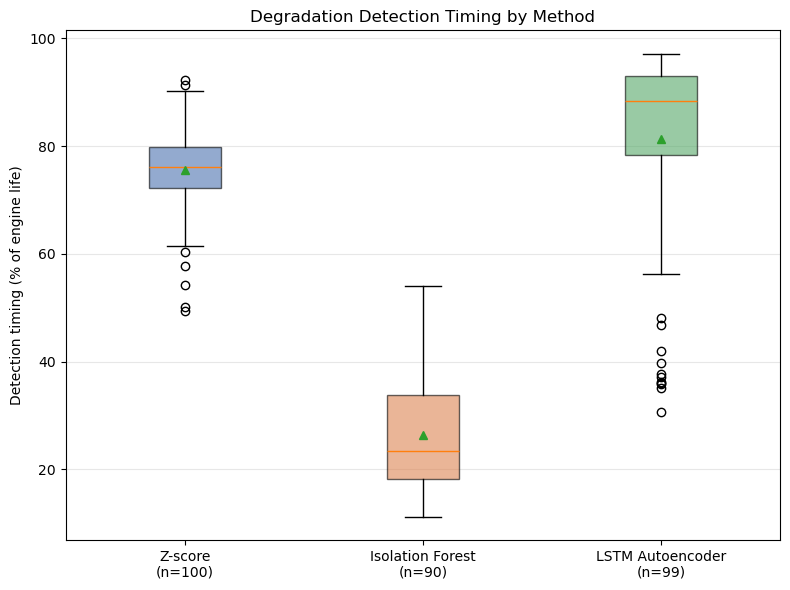

In [30]:
# BoxPlot
fig, ax = plt.subplots(figsize=(8, 6))

data_to_plot = [
    three_way_df['zscore_earliest_pct'].dropna(),
    three_way_df['iso_flag_pct'].dropna(),
    three_way_df['lstm_flag_pct'].dropna()
]

labels = [f'Z-score\n(n={len(data_to_plot[0])})', 
          f'Isolation Forest\n(n={len(data_to_plot[1])})', 
          f'LSTM Autoencoder\n(n={len(data_to_plot[2])})']

bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, showmeans=True)

colors = ['#4C72B0', '#DD8452', '#55A868']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel('Detection timing (% of engine life)')
ax.set_title('Degradation Detection Timing by Method')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("../outputs/three_way_boxplot_comparison.png", dpi=150)
plt.show()

In [32]:
print("=== FINAL CONFIRMED RESULTS ===")
print(f"Z-score: {zscore_results_df['zscore_earliest_pct'].notna().sum()}/100, median={zscore_results_df['zscore_earliest_pct'].median():.1f}%, range={zscore_results_df['zscore_earliest_pct'].min():.1f}-{zscore_results_df['zscore_earliest_pct'].max():.1f}%")
print(f"Isolation Forest: {iso_results_df['iso_flag_pct'].notna().sum()}/100, median={iso_results_df['iso_flag_pct'].median():.1f}%, range={iso_results_df['iso_flag_pct'].min():.1f}-{iso_results_df['iso_flag_pct'].max():.1f}%")
print(f"LSTM: {lstm_results_df['lstm_flag_pct'].notna().sum()}/100, median={lstm_results_df['lstm_flag_pct'].median():.1f}%, range={lstm_results_df['lstm_flag_pct'].min():.1f}-{lstm_results_df['lstm_flag_pct'].max():.1f}%")

print(f"\nIsoForest reliability - units <50% persistent: {(recovery_df['pct_anomalous_after_flag'] < 0.5).sum()}/{len(recovery_df)}")
print(f"LSTM reliability - units <50% persistent: {(recovery_lstm_df['pct_anomalous_after_flag'] < 0.5).sum()}/{len(recovery_lstm_df)}")

print(f"\nLSTM k=1.5 median: {lstm_results_k15_df['lstm_flag_pct'].median():.1f}%")
print(f"LSTM k=2 (adopted) median: {lstm_results_df['lstm_flag_pct'].median():.1f}%")

print(f"\nCorrelation matrix:")
print(three_way_df[["zscore_earliest_pct","iso_flag_pct","lstm_flag_pct"]].corr())

=== FINAL CONFIRMED RESULTS ===
Z-score: 100/100, median=76.2%, range=49.4-92.2%
Isolation Forest: 90/100, median=23.3%, range=11.2-54.0%
LSTM: 99/100, median=88.3%, range=30.7-97.2%

IsoForest reliability - units <50% persistent: 11/90
LSTM reliability - units <50% persistent: 18/99

LSTM k=1.5 median: 73.5%
LSTM k=2 (adopted) median: 88.3%

Correlation matrix:
                     zscore_earliest_pct  iso_flag_pct  lstm_flag_pct
zscore_earliest_pct             1.000000      0.275010      -0.037941
iso_flag_pct                    0.275010      1.000000       0.004821
lstm_flag_pct                  -0.037941      0.004821       1.000000
